## 感知机 

二分类模型

$f(x) = sign(w*x + b)$

损失函数 $L(w, b) = -\Sigma{y_{i}(w*x_{i} + b)}$

---
#### 算法

随即梯度下降法 Stochastic Gradient Descent

随机抽取一个误分类点使其梯度下降。

$w = w + \eta y_{i}x_{i}$

$b = b + \eta y_{i}$

当实例点被误分类，即位于分离超平面的错误侧，则调整w, b的值，使分离超平面向该无分类点的一侧移动，直至误分类点被正确分类

拿出iris数据集中两个分类的数据和[sepal length，sepal width]作为特征

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['label'] = iris.target

In [3]:
#
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'label']
df.label.value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

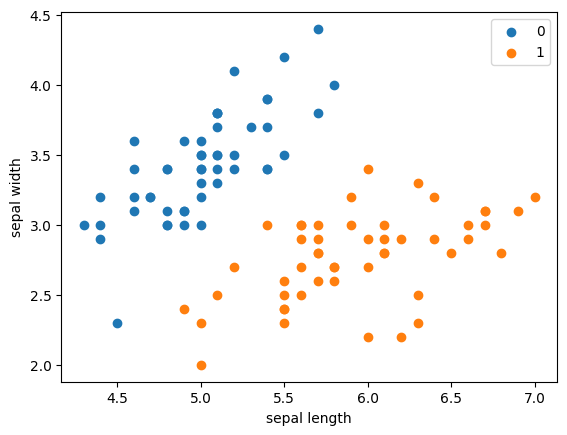

In [4]:
plt.scatter(df[:50]['sepal length'], df[:50]['sepal width'], label='0')
plt.scatter(df[50:100]['sepal length'], df[50:100]['sepal width'], label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

In [5]:
data = np.array(df.iloc[:100, [0, 1, -1]])

In [6]:
X, y = data[:,:-1], data[:,-1]

In [7]:
y = np.array([1 if i == 1 else -1 for i in y])

## Perceptron

In [8]:
# The hand-written SGD implementation lives in Perceptron/perceptron.py so tests and this notebook share one source.
try:
    from Perceptron.perceptron import Perceptron
except ModuleNotFoundError:
    from perceptron import Perceptron

In [9]:
perceptron = Perceptron()
perceptron.fit(X, y)

'Perceptron Model!'

/var/folders/4_/mc0s51zd1vv2pnbqgj28s9140000gn/T/ipykernel_91825/3566099276.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(data[:50, 0], data[:50, 1], 'bo', color='blue', label='0')
/var/folders/4_/mc0s51zd1vv2pnbqgj28s9140000gn/T/ipykernel_91825/3566099276.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(data[50:100, 0], data[50:100, 1], 'bo', color='orange', label='1')


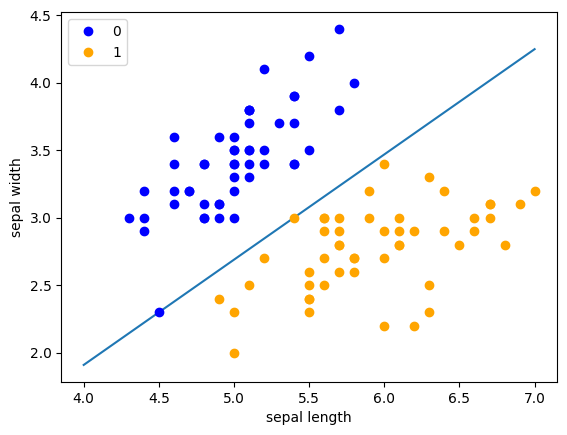

In [10]:
x_points = np.linspace(4, 7,10)
y_ = -(perceptron.w[0]*x_points + perceptron.b)/perceptron.w[1]
plt.plot(x_points, y_)

plt.plot(data[:50, 0], data[:50, 1], 'bo', color='blue', label='0')
plt.plot(data[50:100, 0], data[50:100, 1], 'bo', color='orange', label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

## scikit-learn Perceptron

In [11]:
from sklearn.linear_model import Perceptron

In [12]:
clf = Perceptron(fit_intercept=False, max_iter=1000, shuffle=False, random_state=0)
clf.fit(X, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,False
,max_iter,1000
,tol,0.001
,shuffle,False
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [13]:
# Weights assigned to the features.
print(clf.coef_)

[[ 16.3 -24.2]]


In [14]:
# 截距 Constants in decision function.
print(clf.intercept_)

[0.]


/var/folders/4_/mc0s51zd1vv2pnbqgj28s9140000gn/T/ipykernel_91825/2138998582.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(data[:50, 0], data[:50, 1], 'bo', color='blue', label='0')
/var/folders/4_/mc0s51zd1vv2pnbqgj28s9140000gn/T/ipykernel_91825/2138998582.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(data[50:100, 0], data[50:100, 1], 'bo', color='orange', label='1')


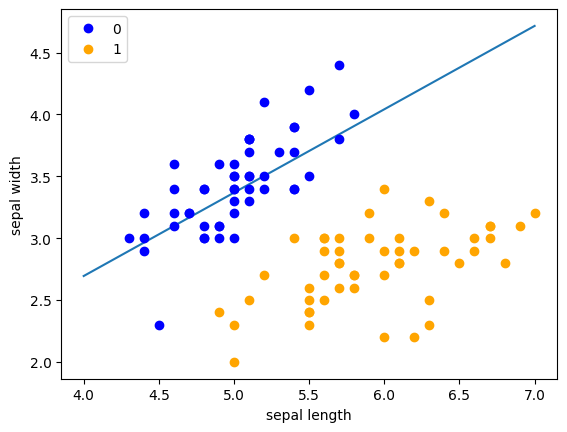

In [15]:
x_ponits = np.arange(4, 8)
y_ = -(clf.coef_[0][0]*x_ponits + clf.intercept_)/clf.coef_[0][1]
plt.plot(x_ponits, y_)

plt.plot(data[:50, 0], data[:50, 1], 'bo', color='blue', label='0')
plt.plot(data[50:100, 0], data[50:100, 1], 'bo', color='orange', label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()